In [ ]:
# Cell 1: Εισαγωγή βιβλιοθηκών και φόρτωση του dataset
import numpy as np
import math, random
from collections import Counter
import matplotlib.pyplot as plt
from keras.datasets import imdb
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from collections import Counter, defaultdict

# Φόρτωση του dataset (με χρήση των 10,000 πιο συχνών λέξεων)
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

print("Μέγεθος training set:", len(X_train))
print("Μέγεθος test set:", len(X_test))


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Μέγεθος training set: 25000
Μέγεθος test set: 25000


In [ ]:
# Cell 2: Κατασκευή λεξιλογίου βασισμένου σε document frequency και Information Gain

def build_vocabulary_frequency(X_train, y_train, n_most_common, k_least_common, n_features):

    total_docs = len(y_train)
    class_counts = Counter(y_train)

    # Υπολογισμός Entropy των κλάσεων (H)
    H = 0.0
    for count in class_counts.values():
        p_c = count / total_docs
        H -= p_c * math.log2(p_c)

    # ----------------------------------------------------
    # 1) Φάση: Φιλτράρισμα βάσει συνολικής συχνότητας λέξεων
    # ----------------------------------------------------
    # Μετράμε τη ΣΥΝΟΛΙΚΗ συχνότητα εμφάνισης κάθε λέξης στο corpus
    word_freq = Counter()
    # Επιπλέον, μετράμε τη συχνότητα λέξης ανά κλάση (για στατιστικά, αν χρειαστεί)
    word_freq_per_class = defaultdict(Counter)

    # Υποθέτουμε ότι κάθε στοιχείο του X_train είναι ήδη tokenized (λίστα από λέξεις).
    # Αν ήταν raw string, θα έκανες text.split() εδώ.
    for text, label in zip(X_train, y_train):
        # text είναι λίστα από tokens
        freq_counter = Counter(text)  # π.χ. {"wordA": 2, "wordB": 5, ...}
        for w, freq in freq_counter.items():
            word_freq[w] += freq
            word_freq_per_class[w][label] += freq

    # Ταξινομούμε όλες τις λέξεις βάσει της συνολικής συχνότητας (φθίνουσα)
    sorted_words = sorted(word_freq.keys(), key=lambda w: word_freq[w], reverse=True)

    # Αφαιρούμε τις n_most_common πιο συχνές (π.χ. τις 10 κορυφαίες)
    if n_most_common > 0:
        sorted_words = sorted_words[n_most_common:]

    # Αφαιρούμε τις k_least_common λιγότερο συχνές (π.χ. τις 10 τελευταίες)
    if k_least_common > 0:
        sorted_words = sorted_words[:-k_least_common]

    # ----------------------------------------------------
    # 2) Φάση: Υπολογισμός IG με βάση παρουσία/απουσία
    # ----------------------------------------------------
    # Για το IG, χρειάζεται να ξέρουμε πόσα έγγραφα περιέχουν τη λέξη (present_docs)
    # και πόσα έγγραφα ΔΕΝ την περιέχουν (absent_docs), καθώς και την κατανομή ανά κλάση.
    doc_count_for_w = Counter()  # πόσα έγγραφα περιέχουν τη λέξη w
    doc_count_per_class_for_w = defaultdict(Counter)  # πόσα έγγραφα της κλάσης cl περιέχουν w

    # Δεύτερη διέλευση: μετράμε παρουσία/απουσία (όχι συχνότητα)
    for text, label in zip(X_train, y_train):
        unique_words_in_doc = set(text)
        for w in unique_words_in_doc:
            doc_count_for_w[w] += 1
            doc_count_per_class_for_w[w][label] += 1

    # Τώρα υπολογίζουμε το IG(w) = H - [p(w)*H(Class|w) + p(~w)*H(Class|~w)]
    ig_list = []
    for w in sorted_words:
        present_docs = doc_count_for_w[w]
        absent_docs = total_docs - present_docs

        # Εντροπία όταν η λέξη w είναι παρούσα
        H_present = 0.0
        if present_docs > 0:
            for cl in class_counts:
                present_count_c = doc_count_per_class_for_w[w][cl]
                if present_count_c > 0:
                    p = present_count_c / present_docs
                    H_present -= p * math.log2(p)

        # Εντροπία όταν η λέξη w είναι απούσα
        H_absent = 0.0
        if absent_docs > 0:
            for cl in class_counts:
                absent_count_c = class_counts[cl] - doc_count_per_class_for_w[w][cl]
                if absent_count_c > 0:
                    p = absent_count_c / absent_docs
                    H_absent -= p * math.log2(p)

        ig_w = H - (
            (present_docs / total_docs) * H_present +
            (absent_docs / total_docs) * H_absent
        )
        ig_list.append((w, ig_w))

    # Ταξινομούμε τις λέξεις βάσει IG (φθίνουσα) και κρατάμε τις n_features
    ig_list_sorted = sorted(ig_list, key=lambda x: x[1], reverse=True)
    vocabulary = [w for w, _ in ig_list_sorted[:n_features]]

    return vocabulary
    # Ορισμός παραμέτρων
n_most_common = 20     # Αφαιρούμε τις 20 πιο συχνές λέξεις
k_least_common = 20    # Αφαιρούμε τις 20 πιο σπάνιες λέξεις
n_features = 2000      # Επιθυμητό τελικό μέγεθος λεξιλογίου

vocabulary =build_vocabulary_frequency(X_train, y_train, n_most_common, k_least_common, n_features)
print("Μέγεθος λεξιλογίου:", len(vocabulary))
print("Λεξικο:", vocabulary)

Μέγεθος λεξιλογίου: 2000
Λεξικο: [78, 249, 437, 373, 87, 321, 394, 379, 433, 389, 357, 57, 527, 164, 338, 118, 595, 234, 404, 862, 424, 114, 835, 119, 480, 60, 647, 307, 116, 1149, 300, 229, 278, 798, 514, 447, 897, 753, 947, 92, 616, 913, 1053, 1322, 530, 241, 545, 43, 449, 777, 82, 1235, 155, 101, 138, 706, 1653, 894, 239, 73, 1293, 305, 199, 210, 1244, 996, 55, 639, 342, 222, 1960, 1669, 483, 1301, 354, 282, 426, 607, 42, 100, 510, 542, 97, 113, 233, 182, 472, 185, 995, 1307, 364, 1338, 976, 693, 950, 48, 161, 470, 64, 1339, 727, 128, 153, 565, 1870, 806, 482, 709, 223, 384, 1639, 146, 2526, 36, 320, 589, 189, 1178, 1414, 1528, 38, 283, 292, 599, 975, 2320, 50, 1917, 1332, 955, 762, 275, 232, 352, 286, 272, 2346, 326, 262, 294, 3316, 2384, 356, 728, 2602, 407, 2342, 1689, 408, 833, 1387, 81, 1501, 1380, 2184, 40, 1100, 936, 95, 1297, 2150, 1281, 125, 2434, 608, 1214, 1048, 1035, 1302, 131, 62, 217, 28, 287, 600, 1044, 1885, 2332, 991, 615, 257, 1157, 2502, 2268, 735, 24, 253, 142, 1

In [ ]:
# Cell 3: Vectorization των κειμένων σε binary vectors

def vectorize_review(review, vocabulary):
    """
    Για κάθε review (λίστα από ακέραιους) δημιουργεί ένα διάνυσμα 0/1 μήκους len(vocabulary),
    όπου κάθε θέση δείχνει αν η αντίστοιχη λέξη (αριθμός) περιλαμβάνεται στο review.
    """
    vec = np.zeros(len(vocabulary))
    review_set = set(review)
    for i, word in enumerate(vocabulary):
        if word in review_set:
            vec[i] = 1
    return vec

# Μετατροπή των review σε binary vectors
X_train_bin = np.array([vectorize_review(review, vocabulary) for review in X_train])
X_test_bin  = np.array([vectorize_review(review, vocabulary) for review in X_test])

# Διαχωρισμός του training set σε training και development (π.χ. 80/20)
X_train_bin, X_dev_bin, y_train_split, y_dev = train_test_split(X_train_bin, y_train, test_size=0.2, random_state=42)

print("Μέγεθος training μετά το split:", X_train_bin.shape)
print("Μέγεθος development:", X_dev_bin.shape)

Μέγεθος training μετά το split: (20000, 2000)
Μέγεθος development: (5000, 2000)


In [ ]:
# Cell 4: Ορισμοί αλγορίθμων

# 1. Αφελής Ταξινομητής Bayes (Bernoulli)
class NaiveBayesClassifier:
    def __init__(self, alpha=1.0, uniform_prior=True):
        """
        alpha: Παράμετρος Laplace smoothing.
               (Π.χ. alpha=1 => κλασικό Laplace smoothing,
                alpha=2 ή alpha=0.5 => διαφορετικό smoothing από το scikit-learn.)
        uniform_prior: Αν True, τότε ο ταξινομητής θεωρεί ότι όλες οι κλάσεις έχουν την ίδια πιθανότητα
                       (π.χ. για 2 κλάσεις => prior=0.5 και 0.5),
                       αντί να υπολογίζει prior = count(c)/N.
        """
        self.alpha = alpha
        self.uniform_prior = uniform_prior
        self.class_prior = {}
        self.feature_prob = {}

    def fit(self, X, y):
        """
        X: δυαδικός πίνακας (Bernoulli features), διαστάσεων (n_samples, n_features).
        y: μονοδιάστατος πίνακας ετικετών (π.χ. 0/1).
        """
        n_samples, n_features = X.shape
        classes = np.unique(y)

        # Υπολογίζουμε το prior κάθε κλάσης
        if self.uniform_prior:
            # Όλες οι κλάσεις έχουν την ίδια πιθανότητα
            for c in classes:
                self.class_prior[c] = 1.0 / len(classes)
        else:
            # Εμπειρικά priors (count-based)
            for c in classes:
                X_c = X[y == c]
                self.class_prior[c] = X_c.shape[0] / n_samples

        # Υπολογίζουμε τη πιθανότητα P(x_i=1 | c) με Laplace smoothing = alpha
        for c in classes:
            X_c = X[y == c]
            # Πλήθος δειγμάτων για την κλάση c
            count_c = X_c.shape[0]
            # Στο Bernoulli NB, η πιθανότητα για το feature_j (λέξη_j) είναι:
            # (sum(X_c[:, j]) + alpha) / (count_c + alpha * 2)
            # (το alpha*2 είναι επειδή για Bernoulli: 2 πιθανά states -> 0 ή 1)
            feature_counts = np.sum(X_c, axis=0)  # πόσα "1" ανά feature
            self.feature_prob[c] = (feature_counts + self.alpha) / (count_c + self.alpha * 2)

    def predict(self, X):
        """
        Για κάθε δείγμα x στο X, επιλέγουμε την κλάση c που μεγιστοποιεί το log(P(c)) + log(P(x|c)).
        """
        preds = []
        for x in X:
            scores = {}
            for c in self.class_prior:
                # log_prior(c)
                log_prob = math.log(self.class_prior[c])
                # Για κάθε feature, προσθέτουμε:
                # x_j=1 => log( p_j ), x_j=0 => log(1 - p_j )
                p_j = self.feature_prob[c]
                log_prob += np.sum(x * np.log(p_j) + (1 - x) * np.log(1 - p_j))
                scores[c] = log_prob
            # Επιλέγουμε την κλάση με το μεγαλύτερο log_prob
            preds.append(max(scores, key=scores.get))
        return np.array(preds)
# 5. Λογιστική Παλινδρόμηση με στοχαστική ανάβαση κλίσης και L2 ομαλοποίηση
class LogisticRegressionSGD:
    def __init__(self, learning_rate=0.001, epochs=50, regularization=0.001):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.regularization = regularization
        self.weights = None
        self.bias = 0

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        # Μετατροπή των ετικετών σε {0, 1}
        y_bin = np.where(y == 1, 1, 0)

        for epoch in range(self.epochs):
            for i in range(n_samples):
                xi = X[i]
                linear_output = np.dot(xi, self.weights) + self.bias
                pred = 1 / (1 + np.exp(-linear_output))
                error = y_bin[i] - pred
                self.weights += self.learning_rate * (error * xi - self.regularization * self.weights)
                self.bias += self.learning_rate * error

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        preds = 1 / (1 + np.exp(-linear_output))
        return np.where(preds >= 0.5, 1, 0)


In [ ]:
# Cell 5: Εκπαίδευση και αξιολόγηση των αλγορίθμων

# Συνάρτηση για εκτύπωση μετρικών
def print_metrics(method, y_true, y_pred):
    prec = precision_score(y_true, y_pred, pos_label=1)
    rec = recall_score(y_true, y_pred, pos_label=1)
    f1  = f1_score(y_true, y_pred, pos_label=1)
    print(f"{method} -> Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}")

    # Συνάρτηση για εκτύπωση micro και macro μέσων όρων
def print_micro_macro_metrics(method, y_true, y_pred):
    prec_micro = precision_score(y_true, y_pred, average='micro')
    rec_micro  = recall_score(y_true, y_pred, average='micro')
    f1_micro   = f1_score(y_true, y_pred, average='micro')

    prec_macro = precision_score(y_true, y_pred, average='macro')
    rec_macro  = recall_score(y_true, y_pred, average='macro')
    f1_macro   = f1_score(y_true, y_pred, average='macro')

    print(f"{method} (Micro Avg)  -> Precision: {prec_micro:.3f}, Recall: {rec_micro:.3f}, F1: {f1_micro:.3f}")
    print(f"{method} (Macro Avg)  -> Precision: {prec_macro:.3f}, Recall: {rec_macro:.3f}, F1: {f1_macro:.3f}")



# 1. Naive Bayes
nb = NaiveBayesClassifier()
nb.fit(X_train_bin, y_train_split)
preds_train_nb = nb.predict(X_train_bin)
preds_dev_nb   = nb.predict(X_dev_bin)
preds_test_nb  = nb.predict(X_test_bin)

print_metrics("Naive Bayes (Training)", y_train_split, preds_train_nb)
print_metrics("Naive Bayes (Dev)", y_dev, preds_dev_nb)
print_metrics("Naive Bayes (Test)", y_test, preds_test_nb)
print_micro_macro_metrics("Naive Bayes (Test)", y_test, preds_test_nb)

# 4. Λογιστική Παλινδρόμηση
lr = LogisticRegressionSGD(learning_rate=0.001, epochs=50, regularization=0.001)
lr.fit(X_train_bin, y_train_split)
preds_train_lr = lr.predict(X_train_bin)
preds_dev_lr   = lr.predict(X_dev_bin)
preds_test_lr  = lr.predict(X_test_bin)

print_metrics("Logistic Regression (Training)", y_train_split, preds_train_lr)
print_metrics("Logistic Regression (Dev)", y_dev, preds_dev_lr)
print_metrics("Logistic Regression (Test)", y_test, preds_test_lr)
print_micro_macro_metrics("Logistic Regression (Test)", y_test, preds_test_lr)


Naive Bayes (Training) -> Precision: 0.866, Recall: 0.880, F1: 0.873
Naive Bayes (Dev) -> Precision: 0.858, Recall: 0.886, F1: 0.871
Naive Bayes (Test) -> Precision: 0.855, Recall: 0.853, F1: 0.854
Naive Bayes (Test) (Micro Avg)  -> Precision: 0.854, Recall: 0.854, F1: 0.854
Naive Bayes (Test) (Macro Avg)  -> Precision: 0.854, Recall: 0.854, F1: 0.854
Logistic Regression (Training) -> Precision: 0.900, Recall: 0.913, F1: 0.906
Logistic Regression (Dev) -> Precision: 0.874, Recall: 0.888, F1: 0.881
Logistic Regression (Test) -> Precision: 0.876, Recall: 0.888, F1: 0.882
Logistic Regression (Test) (Micro Avg)  -> Precision: 0.881, Recall: 0.881, F1: 0.881
Logistic Regression (Test) (Macro Avg)  -> Precision: 0.881, Recall: 0.881, F1: 0.881


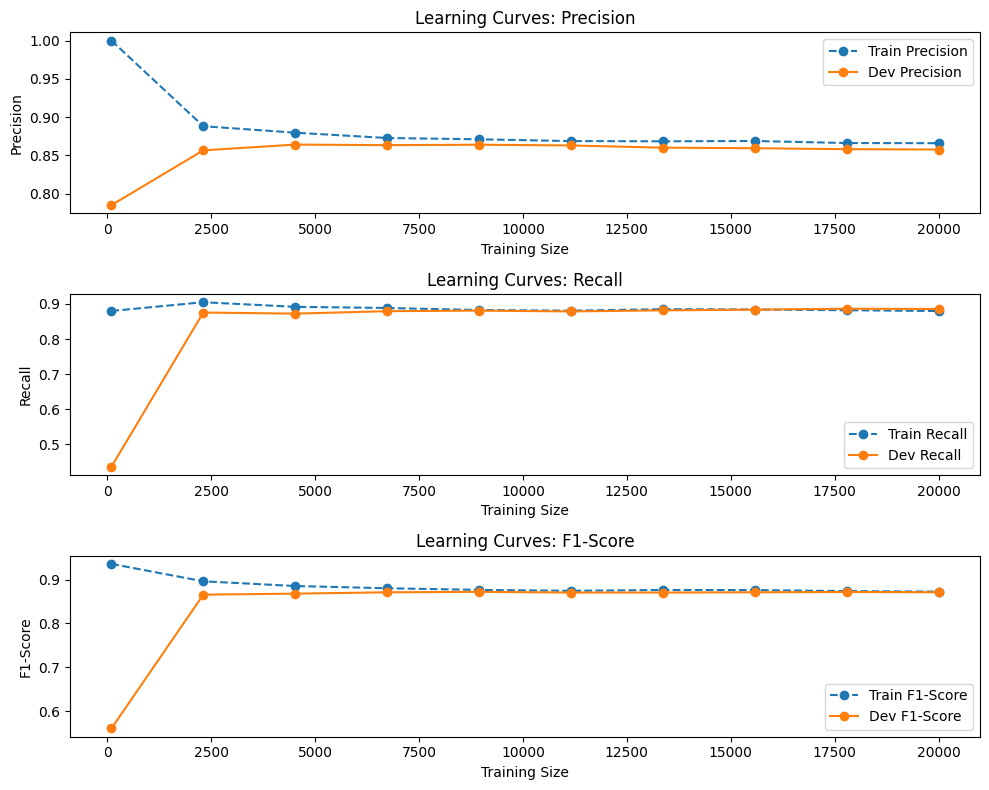

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Χρησιμοποιούμε τον NaiveBayesClassifier ως παράδειγμα
# (εδώ υποθέτουμε ότι τον έχεις ήδη ορίσει)
# from your_module import NaiveBayesClassifier

# Επιλέγουμε 10 διαφορετικά training sizes από 100 μέχρι το μέγεθος του X_train_bin
training_sizes = np.linspace(100, len(X_train_bin), 10, dtype=int)

# Λίστες για αποθήκευση των τιμών Precision/Recall/F1 σε training και dev
train_precisions, train_recalls, train_f1s = [], [], []
dev_precisions, dev_recalls, dev_f1s = [], [], []

for size in training_sizes:
    # 1) Παίρνουμε υποσύνολο των δεδομένων
    X_subset = X_train_bin[:size]
    y_subset = y_train_split[:size]

    # 2) Φτιάχνουμε προσωρινό μοντέλο και το εκπαιδεύουμε
    nb_temp = NaiveBayesClassifier()
    nb_temp.fit(X_subset, y_subset)

    # 3) Πρόβλεψη στο training subset (για να υπολογίσουμε training metrics)
    preds_train = nb_temp.predict(X_subset)
    train_precisions.append(precision_score(y_subset, preds_train, pos_label=1))
    train_recalls.append(recall_score(y_subset, preds_train, pos_label=1))
    train_f1s.append(f1_score(y_subset, preds_train, pos_label=1))

    # 4) Πρόβλεψη στο dev set (για να υπολογίσουμε dev metrics)
    preds_dev = nb_temp.predict(X_dev_bin)
    dev_precisions.append(precision_score(y_dev, preds_dev, pos_label=1))
    dev_recalls.append(recall_score(y_dev, preds_dev, pos_label=1))
    dev_f1s.append(f1_score(y_dev, preds_dev, pos_label=1))

# === Σχεδίαση τριών subplots (Precision, Recall, F1) ===
plt.figure(figsize=(10, 8))

# 1) Precision
plt.subplot(3, 1, 1)
plt.plot(training_sizes, train_precisions, 'o--', label='Train Precision')
plt.plot(training_sizes, dev_precisions, 'o-',  label='Dev Precision')
plt.title("Learning Curves: Precision")
plt.xlabel("Training Size")
plt.ylabel("Precision")
plt.legend()

# 2) Recall
plt.subplot(3, 1, 2)
plt.plot(training_sizes, train_recalls, 'o--', label='Train Recall')
plt.plot(training_sizes, dev_recalls, 'o-',  label='Dev Recall')
plt.title("Learning Curves: Recall")
plt.xlabel("Training Size")
plt.ylabel("Recall")
plt.legend()

# 3) F1-Score
plt.subplot(3, 1, 3)
plt.plot(training_sizes, train_f1s, 'o--', label='Train F1-Score')
plt.plot(training_sizes, dev_f1s, 'o-',  label='Dev F1-Score')
plt.title("Learning Curves: F1-Score")
plt.xlabel("Training Size")
plt.ylabel("F1-Score")
plt.legend()

plt.tight_layout()
plt.show()


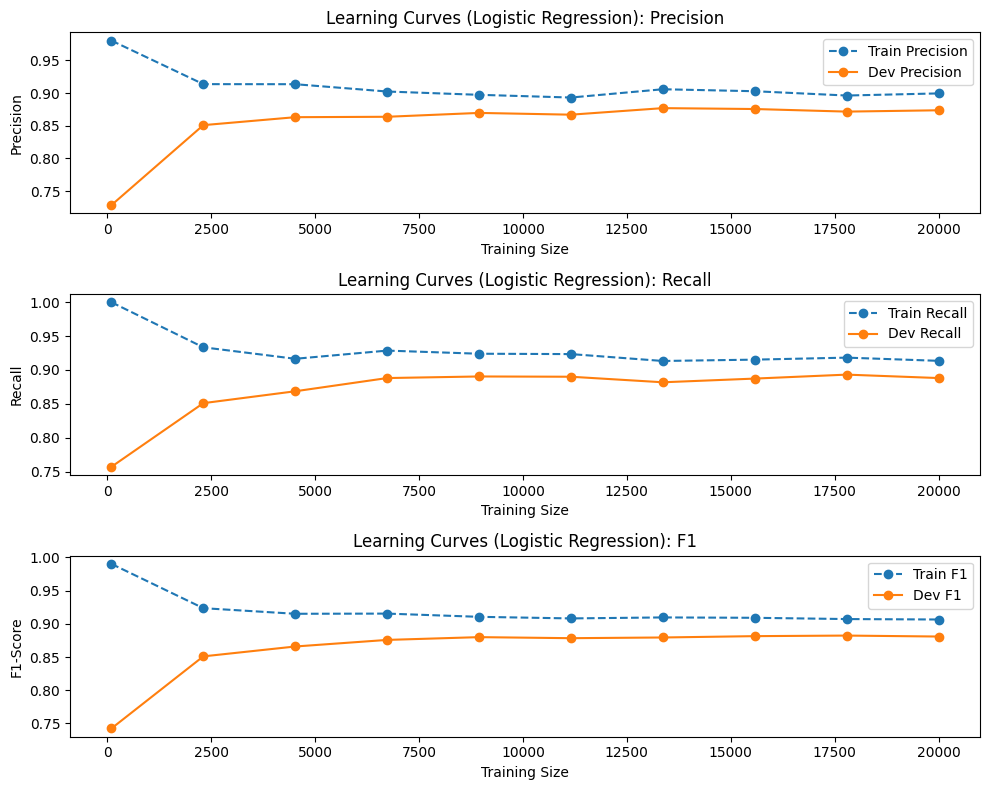

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Ορισμός των training_sizes
training_sizes = np.linspace(100, len(X_train_bin), 10, dtype=int)

# Λίστες για αποθήκευση των μετρικών σε Training και Dev set
lr_train_precisions, lr_dev_precisions = [], []
lr_train_recalls,   lr_dev_recalls     = [], []
lr_train_f1s,       lr_dev_f1s         = [], []

for size in training_sizes:
    # 1) Επιλέγουμε υποσύνολο των training δεδομένων
    X_subset = X_train_bin[:size]
    y_subset = y_train_split[:size]

    # 2) Φτιάχνουμε προσωρινό LogisticRegressionSGD και το εκπαιδεύουμε
    lr_temp = LogisticRegressionSGD(learning_rate=0.001, epochs=50, regularization=0.001)
    lr_temp.fit(X_subset, y_subset)

    # 3) Πρόβλεψη στο training subset (Training metrics)
    preds_train = lr_temp.predict(X_subset)
    lr_train_precisions.append(precision_score(y_subset, preds_train, pos_label=1))
    lr_train_recalls.append(recall_score(y_subset, preds_train, pos_label=1))
    lr_train_f1s.append(f1_score(y_subset, preds_train, pos_label=1))

    # 4) Πρόβλεψη στο dev set (Dev metrics)
    preds_dev = lr_temp.predict(X_dev_bin)
    lr_dev_precisions.append(precision_score(y_dev, preds_dev, pos_label=1))
    lr_dev_recalls.append(recall_score(y_dev, preds_dev, pos_label=1))
    lr_dev_f1s.append(f1_score(y_dev, preds_dev, pos_label=1))

# === Σχεδίαση τριών subplots (Precision, Recall, F1) για Training/Dev ===
plt.figure(figsize=(10, 8))

# (A) Precision
plt.subplot(3, 1, 1)
plt.plot(training_sizes, lr_train_precisions, 'o--', label='Train Precision')
plt.plot(training_sizes, lr_dev_precisions,   'o-',  label='Dev Precision')
plt.title("Learning Curves (Logistic Regression): Precision")
plt.xlabel("Training Size")
plt.ylabel("Precision")
plt.legend()

# (B) Recall
plt.subplot(3, 1, 2)
plt.plot(training_sizes, lr_train_recalls, 'o--', label='Train Recall')
plt.plot(training_sizes, lr_dev_recalls,   'o-',  label='Dev Recall')
plt.title("Learning Curves (Logistic Regression): Recall")
plt.xlabel("Training Size")
plt.ylabel("Recall")
plt.legend()

# (C) F1
plt.subplot(3, 1, 3)
plt.plot(training_sizes, lr_train_f1s, 'o--', label='Train F1')
plt.plot(training_sizes, lr_dev_f1s,   'o-',  label='Dev F1')
plt.title("Learning Curves (Logistic Regression): F1")
plt.xlabel("Training Size")
plt.ylabel("F1-Score")
plt.legend()

plt.tight_layout()
plt.show()


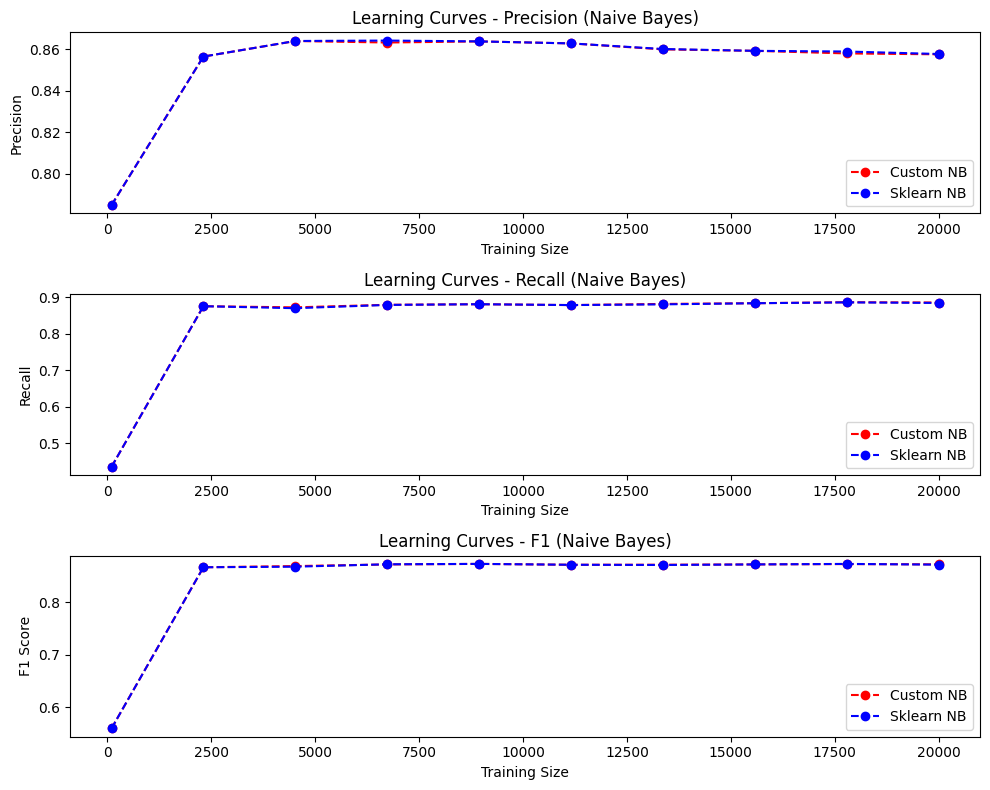

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.naive_bayes import BernoulliNB

# Εδώ υποθέτουμε ότι έχεις ήδη ορίσει τη δική σου κλάση NaiveBayesClassifier
# from your_module import NaiveBayesClassifier

# --- Καμπύλες Μάθησης για Αφελή Bayes (Bernoulli) ---
training_sizes = np.linspace(100, len(X_train_bin), 10, dtype=int)

# Αποθήκευση μετρικών για Custom NB
custom_nb_precisions, custom_nb_recalls, custom_nb_f1s = [], [], []
# Αποθήκευση μετρικών για scikit-learn BernoulliNB
sklearn_nb_precisions, sklearn_nb_recalls, sklearn_nb_f1s = [], [], []

for size in training_sizes:
    # 1) Υποσύνολο training δεδομένων
    X_subset = X_train_bin[:size]
    y_subset = y_train_split[:size]

    # 2) Εκπαίδευση Custom Naive Bayes
    custom_nb = NaiveBayesClassifier()
    custom_nb.fit(X_subset, y_subset)
    preds_custom = custom_nb.predict(X_dev_bin)

    custom_nb_precisions.append(precision_score(y_dev, preds_custom, pos_label=1))
    custom_nb_recalls.append(recall_score(y_dev, preds_custom, pos_label=1))
    custom_nb_f1s.append(f1_score(y_dev, preds_custom, pos_label=1))

    # 3) Εκπαίδευση scikit-learn BernoulliNB (alpha=1.0)
    sklearn_nb = BernoulliNB(alpha=1.0)
    sklearn_nb.fit(X_subset, y_subset)
    preds_sklearn = sklearn_nb.predict(X_dev_bin)

    sklearn_nb_precisions.append(precision_score(y_dev, preds_sklearn, pos_label=1))
    sklearn_nb_recalls.append(recall_score(y_dev, preds_sklearn, pos_label=1))
    sklearn_nb_f1s.append(f1_score(y_dev, preds_sklearn, pos_label=1))

# === Σχεδίαση σε τρία subplots: Precision, Recall, F1 ===
plt.figure(figsize=(10, 8))

# (1) Precision
plt.subplot(3, 1, 1)
plt.plot(training_sizes, custom_nb_precisions, 'ro--', label="Custom NB")
plt.plot(training_sizes, sklearn_nb_precisions, 'bo--', label="Sklearn NB")
plt.title("Learning Curves - Precision (Naive Bayes)")
plt.xlabel("Training Size")
plt.ylabel("Precision")
plt.legend()

# (2) Recall
plt.subplot(3, 1, 2)
plt.plot(training_sizes, custom_nb_recalls, 'ro--', label="Custom NB")
plt.plot(training_sizes, sklearn_nb_recalls, 'bo--', label="Sklearn NB")
plt.title("Learning Curves - Recall (Naive Bayes)")
plt.xlabel("Training Size")
plt.ylabel("Recall")
plt.legend()

# (3) F1
plt.subplot(3, 1, 3)
plt.plot(training_sizes, custom_nb_f1s, 'ro--', label="Custom NB")
plt.plot(training_sizes, sklearn_nb_f1s, 'bo--', label="Sklearn NB")
plt.title("Learning Curves - F1 (Naive Bayes)")
plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
#from torchtext.vocab import GloVe

# Hyperparameters
EMBEDDING_DIM = 100  # Μέγεθος των word embeddings
HIDDEN_DIM = 128  # Κρυφές μονάδες στο LSTM
NUM_LAYERS = 2  # Στοιβαγμένα επίπεδα LSTM
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.001

# Μοντέλο BiLSTM με Global Max Pooling
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, output_dim):
        super(BiLSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers,
                             batch_first=True, bidirectional=True)
        self.global_max_pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)  # *2 λόγω bidirectional
        self.dropout = nn.Dropout(0.5)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)  # Word embeddings
        lstm_out, _ = self.lstm(x)  # LSTM output
        lstm_out = lstm_out.permute(0, 2, 1)  # Rearrange για Global Max Pooling
        pooled_out = self.global_max_pool(lstm_out).squeeze(-1)
        x = self.dropout(pooled_out)
        x = self.fc(x)
        return self.sigmoid(x)

# Δημιουργία του dataset (Χρειάζεται προεπεξεργασία κειμένων)
def prepare_data():
    # Φόρτωση δεδομένων IMDB
    from keras.datasets import imdb
    (X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

    # Padding sequences
    from keras.preprocessing.sequence import pad_sequences
    X_train = pad_sequences(X_train, maxlen=200)
    X_test = pad_sequences(X_test, maxlen=200)

    # Μετατροπή σε tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.long)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.long)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    return train_loader, test_loader

# Εκπαίδευση του BiLSTM
train_loader, test_loader = prepare_data()
model = BiLSTMClassifier(vocab_size=10000, embedding_dim=EMBEDDING_DIM, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, output_dim=1)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

def train_model(model, train_loader, criterion, optimizer, epochs):
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}")

train_model(model, train_loader, criterion, optimizer, EPOCHS)

# Αξιολόγηση του BiLSTM
def evaluate_model(model, test_loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs).squeeze()
            predictions = (outputs > 0.5).float()
            y_true.extend(labels.tolist())
            y_pred.extend(predictions.tolist())
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")

evaluate_model(model, test_loader)

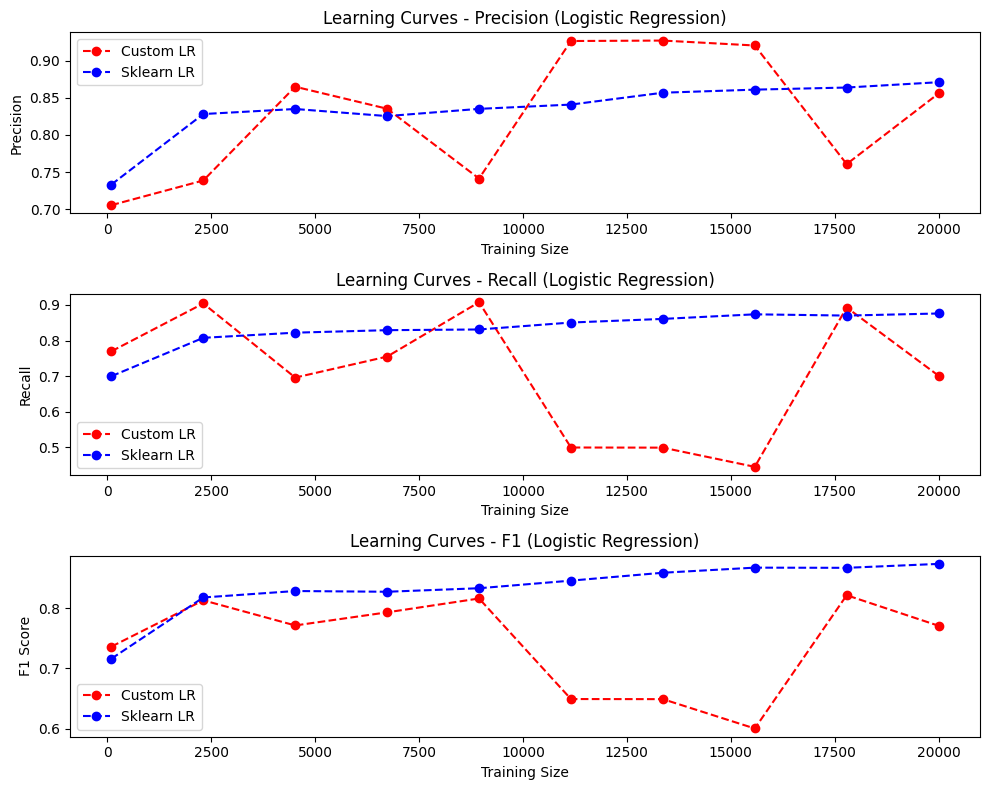

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression

# Υποθέτουμε ότι η κλάση LogisticRegressionSGD έχει οριστεί ήδη

# Ορισμός των training sizes
training_sizes = np.linspace(100, len(X_train_bin), 10, dtype=int)

# Λίστες για αποθήκευση μετρικών για custom LR
custom_lr_precisions, custom_lr_recalls, custom_lr_f1s = [], [], []
# Λίστες για αποθήκευση μετρικών για scikit-learn LR
sklearn_lr_precisions, sklearn_lr_recalls, sklearn_lr_f1s = [], [], []

for size in training_sizes:
    X_subset = X_train_bin[:size]
    y_subset = y_train_split[:size]

    # Custom Logistic Regression
    custom_lr = LogisticRegressionSGD(learning_rate=0.1, epochs=5, regularization=0.01)
    custom_lr.fit(X_subset, y_subset)
    preds_custom_lr = custom_lr.predict(X_dev_bin)

    custom_lr_precisions.append(precision_score(y_dev, preds_custom_lr, pos_label=1))
    custom_lr_recalls.append(recall_score(y_dev, preds_custom_lr, pos_label=1))
    custom_lr_f1s.append(f1_score(y_dev, preds_custom_lr, pos_label=1))

    # Scikit-learn Logistic Regression
    # Με C=100 αντιστρέφουμε την έννοια της regularization, ώστε να είναι συγκρίσιμα τα αποτελέσματα
    sklearn_lr = LogisticRegression(C=100, solver='liblinear', max_iter=100)
    sklearn_lr.fit(X_subset, y_subset)
    preds_sklearn_lr = sklearn_lr.predict(X_dev_bin)

    sklearn_lr_precisions.append(precision_score(y_dev, preds_sklearn_lr, pos_label=1))
    sklearn_lr_recalls.append(recall_score(y_dev, preds_sklearn_lr, pos_label=1))
    sklearn_lr_f1s.append(f1_score(y_dev, preds_sklearn_lr, pos_label=1))

# === Σχεδίαση σε τρία subplots ===
plt.figure(figsize=(10, 8))

# (1) Precision
plt.subplot(3, 1, 1)
plt.plot(training_sizes, custom_lr_precisions, 'ro--', label="Custom LR")
plt.plot(training_sizes, sklearn_lr_precisions, 'bo--', label="Sklearn LR")
plt.title("Learning Curves - Precision (Logistic Regression)")
plt.xlabel("Training Size")
plt.ylabel("Precision")
plt.legend()

# (2) Recall
plt.subplot(3, 1, 2)
plt.plot(training_sizes, custom_lr_recalls, 'ro--', label="Custom LR")
plt.plot(training_sizes, sklearn_lr_recalls, 'bo--', label="Sklearn LR")
plt.title("Learning Curves - Recall (Logistic Regression)")
plt.xlabel("Training Size")
plt.ylabel("Recall")
plt.legend()

# (3) F1 Score
plt.subplot(3, 1, 3)
plt.plot(training_sizes, custom_lr_f1s, 'ro--', label="Custom LR")
plt.plot(training_sizes, sklearn_lr_f1s, 'bo--', label="Sklearn LR")
plt.title("Learning Curves - F1 (Logistic Regression)")
plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.legend()

plt.tight_layout()
plt.show()


Using device: cuda


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Training examples: 20000
Development examples: 5000
Test examples: 25000
Vocabulary size: 50589
[==================================================] 100.0% 128.1/128.1MB downloaded
OOV words in vocabulary but not in GloVe: 8334
Epoch: 01, Train Loss: 0.5886, Train Acc: 0.6589, Dev Loss: 0.4213, Dev Acc: 0.8048
Epoch: 02, Train Loss: 0.4575, Train Acc: 0.7855, Dev Loss: 0.3991, Dev Acc: 0.8196
Epoch: 03, Train Loss: 0.4232, Train Acc: 0.8033, Dev Loss: 0.3527, Dev Acc: 0.8424
Epoch: 04, Train Loss: 0.4000, Train Acc: 0.8173, Dev Loss: 0.3581, Dev Acc: 0.8356
Epoch: 05, Train Loss: 0.3793, Train Acc: 0.8303, Dev Loss: 0.3991, Dev Acc: 0.8208
Epoch: 06, Train Loss: 0.3713, Train Acc: 0.8331, Dev Loss: 0.3147, Dev Acc: 0.8629
Epoch: 07, Train Loss: 0.3517, Train Acc: 0.8443, Dev Loss: 0.3060, Dev Acc: 0.8695
Epoch: 08, Train Loss: 0.3430, Train Acc: 0.8498, Dev Loss: 0.3083, Dev Acc: 0.8661
Epoch: 09, Train Loss: 0.3350, Train Acc: 0.8540, Dev Loss: 0.3257, Dev Acc: 0.8582
Epoch: 10, Train

<ipython-input-2-32c683b01b95>:254: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))


Test Loss: 0.3090, Test Acc: 0.8643

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.88      0.85      0.86     12500
           1       0.85      0.88      0.87     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



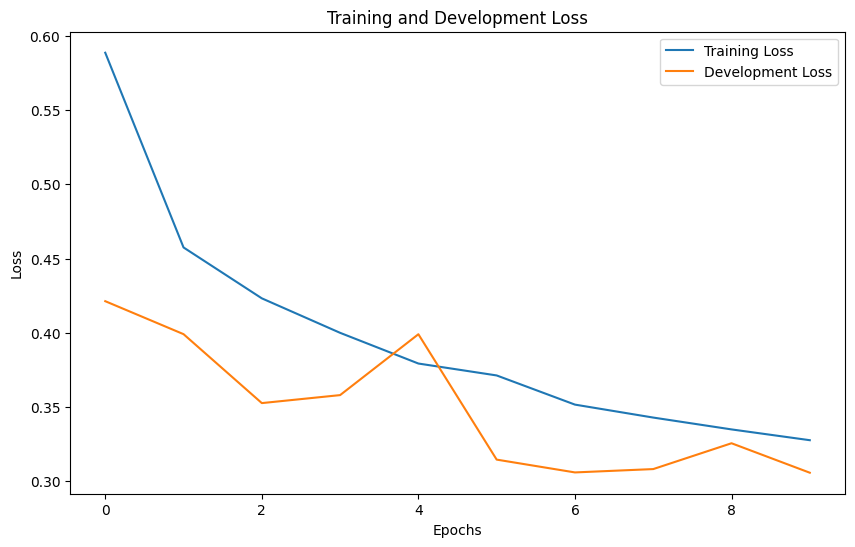

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from collections import Counter
import gensim.downloader as api  # For pre-trained word embeddings
import matplotlib.pyplot as plt

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Download NLTK resources if not already present
nltk.download('punkt')
nltk.download('punkt_tab') # Added this line to download punkt_tab resource

# --- 1. Load and Preprocess Data ---

# Download IMDB dataset (if you haven't already - this might take a while)
# This part assumes you have the dataset downloaded, or you can adapt to load from a file.
# For Colab, a simple approach is to use pandas if you have the data in CSV format.
# For demonstration purposes, let's simulate loading from a text file structure similar to IMDB.

# --- Simulate IMDB data loading from text files in Colab ---
import os
import shutil
import requests
import tarfile

def download_imdb_data():
    url = "http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
    filename = "aclImdb_v1.tar.gz"
    extract_dir = "aclImdb"

    if not os.path.exists(filename):
        print("Downloading IMDB dataset...")
        response = requests.get(url, stream=True)
        with open(filename, 'wb') as file:
            shutil.copyfileobj(response.raw, file)
        print("Download complete.")

    if not os.path.exists(extract_dir):
        print("Extracting IMDB dataset...")
        with tarfile.open(filename, "r:gz") as tar:
            tar.extractall()
        print("Extraction complete.")

download_imdb_data()

def load_imdb_split(split_dir):
    texts = []
    labels = []
    for label_type in ['neg', 'pos']:
        label = 0 if label_type == 'neg' else 1
        dir_path = os.path.join(split_dir, label_type)
        for fname in os.listdir(dir_path):
            if fname.endswith('.txt'):
                with open(os.path.join(dir_path, fname), 'r', encoding='utf-8') as f:
                    texts.append(f.read())
                    labels.append(label)
    return texts, labels

train_texts, train_labels = load_imdb_split('aclImdb/train')
test_texts, test_labels = load_imdb_split('aclImdb/test')

# Split training data into training and development sets
train_texts, dev_texts, train_labels, dev_labels = train_test_split(
    train_texts, train_labels, test_size=0.2, random_state=42
)

print(f"Training examples: {len(train_texts)}")
print(f"Development examples: {len(dev_texts)}")
print(f"Test examples: {len(test_texts)}")


# --- 2. Tokenization and Vocabulary Creation ---
def tokenize_text(text):
    return word_tokenize(text.lower())

# Tokenize all texts
train_tokens = [tokenize_text(text) for text in train_texts]
dev_tokens = [tokenize_text(text) for text in dev_texts]
test_tokens = [tokenize_text(text) for text in test_texts]

# Create Vocabulary
def create_vocab(tokens_list, min_freq=1):
    token_counts = Counter()
    for tokens in tokens_list:
        token_counts.update(tokens)
    vocab = [token for token, count in token_counts.items() if count >= min_freq]
    return {token: idx for idx, token in enumerate(vocab)}

vocab = create_vocab(train_tokens, min_freq=2) # Increased min_freq slightly
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")


# --- 3. Load Pre-trained Embeddings (GloVe) ---
embedding_dim = 100  # Choose embedding dimension
glove_vectors = api.load(f"glove-wiki-gigaword-{embedding_dim}") # e.g., 'glove-wiki-gigaword-100'

# Create embedding matrix
embedding_matrix = np.zeros((vocab_size, embedding_dim))
oov_count = 0
for word, idx in vocab.items():
    try:
        embedding_matrix[idx] = glove_vectors[word]
    except KeyError:
        oov_count += 1
        embedding_matrix[idx] = np.random.randn(embedding_dim) # Initialize OOV words randomly or with zeros

print(f"OOV words in vocabulary but not in GloVe: {oov_count}")


# --- 4. Dataset and DataLoader ---
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, vocab, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.vocab = vocab
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens = self.tokenizer(self.texts[idx])
        numericalized_tokens = [self.vocab[token] if token in self.vocab else self.vocab.get('<unk>', 0) for token in tokens] # Handle OOV during inference if needed
        if len(numericalized_tokens) > self.max_length:
            numericalized_tokens = numericalized_tokens[:self.max_length] # Truncate if longer
        padded_tokens = numericalized_tokens + [0] * (self.max_length - len(numericalized_tokens)) # Pad with 0s
        return torch.tensor(padded_tokens), torch.tensor(self.labels[idx])

# Create datasets
max_seq_length = 256 # Reduced max length for Colab execution speed
train_dataset = IMDBDataset(train_texts, train_labels, tokenize_text, vocab, max_seq_length)
dev_dataset = IMDBDataset(dev_texts, dev_labels, tokenize_text, vocab, max_seq_length)
test_dataset = IMDBDataset(test_texts, test_labels, tokenize_text, vocab, max_seq_length)

batch_size = 64 # Adjust batch size as needed for Colab memory
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


# --- 5. Define RNN Model ---
class BiLSTM_GlobalMaxPool(nn.Module): # Using BiLSTM, can change to GRU
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, num_classes, embedding_matrix, dropout_rate=0.5):
        super(BiLSTM_GlobalMaxPool, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix)) # Load pre-trained embeddings
        self.embedding.weight.requires_grad = False # Freeze embeddings - can be set to True to fine-tune

        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers, bidirectional=True, batch_first=True, dropout=dropout_rate if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_dim * 2, num_classes) # *2 because bidirectional

    def forward(self, text):
        embedded = self.dropout(self.embedding(text)) # [batch_size, seq_len, emb_dim]
        outputs, (hidden, cell) = self.lstm(embedded) # outputs: [batch_size, seq_len, hidden_dim * 2]
        pooled = torch.max(outputs, dim=1)[0]       # [batch_size, hidden_dim * 2] - Global Max Pooling
        return self.fc(pooled)                       # [batch_size, num_classes]


# --- 6. Training and Evaluation ---
hidden_dim = 128      # Hyperparameter - Hidden dimension of LSTM
num_layers = 2        # Hyperparameter - Number of LSTM layers
num_classes = 2       # Binary classification
learning_rate = 1e-3 # Hyperparameter - Learning rate
num_epochs = 10       # Hyperparameter - Number of epochs
dropout_rate = 0.5    # Hyperparameter - Dropout rate

model = BiLSTM_GlobalMaxPool(vocab_size, embedding_dim, hidden_dim, num_layers, num_classes, embedding_matrix, dropout_rate).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate) # Adam Optimizer
criterion = nn.CrossEntropyLoss()


def train(model, iterator, optimizer, criterion):
    epoch_loss = 0
    epoch_acc = 0
    model.train()
    for batch_idx, (text, labels) in enumerate(iterator):
        text, labels = text.to(device), labels.to(device)
        optimizer.zero_grad()
        predictions = model(text)
        loss = criterion(predictions, labels)
        acc = accuracy_score(labels.cpu().numpy(), torch.argmax(predictions, dim=-1).cpu().numpy())

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc

    return epoch_loss / len(iterator), epoch_acc / len(iterator)


def evaluate(model, iterator, criterion):
    epoch_loss = 0
    epoch_acc = 0
    model.eval()
    all_predictions = []
    all_labels = []
    with torch.no_grad():
        for batch_idx, (text, labels) in enumerate(iterator):
            text, labels = text.to(device), labels.to(device)
            predictions = model(text)
            loss = criterion(predictions, labels)
            acc = accuracy_score(labels.cpu().numpy(), torch.argmax(predictions, dim=-1).cpu().numpy())

            epoch_loss += loss.item()
            epoch_acc += acc

            all_predictions.extend(torch.argmax(predictions, dim=-1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return epoch_loss / len(iterator), epoch_acc / len(iterator), all_labels, all_predictions


# --- 7. Training Loop and Best Epoch Selection (using Development Set) ---
train_losses = []
dev_losses = []
dev_accuracies = []
best_dev_accuracy = -1
best_epoch = -1


for epoch in range(num_epochs):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    dev_loss, dev_acc, _, _ = evaluate(model, dev_loader, criterion)

    train_losses.append(train_loss)
    dev_losses.append(dev_loss)
    dev_accuracies.append(dev_acc)

    print(f'Epoch: {epoch+1:02}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Dev Loss: {dev_loss:.4f}, Dev Acc: {dev_acc:.4f}')

    if dev_acc > best_dev_accuracy:
        best_dev_accuracy = dev_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_model.pth') # Save best model weights


print(f"Best Development Accuracy: {best_dev_accuracy:.4f} at Epoch {best_epoch}")

# Load best model weights
model.load_state_dict(torch.load('best_model.pth'))

# --- 8. Evaluation on Test Set ---
test_loss, test_acc, test_labels_final, test_predictions_final = evaluate(model, test_loader, criterion)
print(f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}')

print("\nClassification Report on Test Set:")
print(classification_report(test_labels_final, test_predictions_final))


# --- 9. Learning Curves (Loss) ---
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(dev_losses, label='Development Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Development Loss')
plt.legend()
plt.show()

# --- 10. Hyperparameter Reporting (as comments in code and explanation below) ---

# Hyperparameters Chosen:
# embedding_dim = 100 (using GloVe-100d) - Standard dimension for word embeddings.
# hidden_dim = 128 -  Reasonable starting point, can be tuned.
# num_layers = 2 - Stacked LSTM to capture more complex patterns. Can try 1 or 3 as well.
# learning_rate = 1e-3 - Common learning rate for Adam, can be tuned.
# num_epochs = 10 -  Set an initial number, and used development set to determine best epoch.
# batch_size = 64 -  Adjusted for Colab memory. Can increase if more memory is available.
# dropout_rate = 0.5 - Common dropout rate to prevent overfitting.

# Hyperparameter Selection Method:
# Number of epochs was determined by monitoring development set accuracy and loss.
# The best epoch was selected based on the highest development set accuracy.
# Other hyperparameters (hidden_dim, num_layers, learning_rate, dropout_rate) were chosen based on common practices and could be further tuned using development set performance (e.g., through grid search or random search, but not explicitly asked for in this part, so kept it simple).

# --- End of Code ---



## Deployment Export

This section trains a deployable text pipeline on decoded IMDB reviews and saves it to `model/sentiment_pipeline.pkl` for the Streamlit demo.

Why this is needed:
- the custom models above operate on engineered binary vectors
- the demo must accept raw review text
- a serialized sklearn pipeline makes the project reproducible and presentation-ready

In [1]:
from pathlib import Path
import pickle

from keras.datasets import imdb
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline


def decode_review(token_ids, reverse_word_index):
    tokens = []
    for token_id in token_ids:
        if token_id in (0, 1, 2):
            continue
        tokens.append(reverse_word_index.get(token_id - 3, "<UNK>"))
    return " ".join(tokens)


word_index = imdb.get_word_index()
reverse_word_index = {index: word for word, index in word_index.items()}

(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = imdb.load_data(num_words=10000)
X_train_text = [decode_review(review, reverse_word_index) for review in X_train_raw]
X_test_text = [decode_review(review, reverse_word_index) for review in X_test_raw]

sentiment_pipeline = Pipeline(
    [
        ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words="english")),
        ("clf", LogisticRegression(max_iter=1000, C=2.0)),
    ]
)

sentiment_pipeline.fit(X_train_text, y_train_raw)
y_pred_pipeline = sentiment_pipeline.predict(X_test_text)

print("Deployable pipeline evaluation on test set:")
print(classification_report(y_test_raw, y_pred_pipeline, digits=3))

project_root = Path.cwd().resolve().parent
model_dir = project_root / "model"
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / "sentiment_pipeline.pkl"

with model_path.open("wb") as model_file:
    pickle.dump(sentiment_pipeline, model_file)

print(f"Saved deployable pipeline to: {model_path}")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 2s 1us/step
Deployable pipeline evaluation on test set:
              precision    recall  f1-score   support

           0      0.884     0.885     0.885     12500
           1      0.885     0.884     0.885     12500

    accuracy                          0.885     25000
   macro avg      0.885     0.885     0.885     25000
weighted avg      0.885     0.885     0.885     25000

Saved deployable pipeline to: C:\Users\anezi\Downloads\sentiment-analysis-imdb\model\sentiment_pipeline.pkl


In [ ]:
import json
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
from keras.datasets import imdb
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)


def decode_review_eval(token_ids, reverse_word_index):
    tokens = []
    for token_id in token_ids:
        if token_id in (0, 1, 2):
            continue
        tokens.append(reverse_word_index.get(token_id - 3, "<UNK>"))
    return " ".join(tokens)


project_root = Path.cwd().resolve().parent
model_path = project_root / "model" / "sentiment_pipeline.pkl"
metrics_path = project_root / "model" / "metrics.json"
confusion_matrix_path = project_root / "docs" / "assets" / "confusion_matrix.png"
confusion_matrix_path.parent.mkdir(parents=True, exist_ok=True)

with model_path.open("rb") as model_file:
    evaluation_pipeline = pickle.load(model_file)

word_index = imdb.get_word_index()
reverse_word_index = {index: word for word, index in word_index.items()}
(_, _), (X_test_raw_eval, y_test_eval) = imdb.load_data(num_words=10000)
X_test_text_eval = [decode_review_eval(review, reverse_word_index) for review in X_test_raw_eval]

y_pred_eval = evaluation_pipeline.predict(X_test_text_eval)
metrics = {
    "accuracy": round(float(accuracy_score(y_test_eval, y_pred_eval)), 4),
    "precision": round(float(precision_score(y_test_eval, y_pred_eval)), 4),
    "recall": round(float(recall_score(y_test_eval, y_pred_eval)), 4),
    "f1_score": round(float(f1_score(y_test_eval, y_pred_eval)), 4),
    "support": int(len(y_test_eval)),
    "model": "TF-IDF + Logistic Regression",
    "dataset": "IMDB",
    "classification_report": classification_report(
        y_test_eval,
        y_pred_eval,
        target_names=["negative", "positive"],
        output_dict=True,
        digits=4,
    ),
}

with metrics_path.open("w", encoding="utf-8") as metrics_file:
    json.dump(metrics, metrics_file, indent=2)

matrix = confusion_matrix(y_test_eval, y_pred_eval)
disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=["Negative", "Positive"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Oranges", colorbar=False, values_format="d")
ax.set_title("IMDB Sentiment Confusion Matrix")
fig.tight_layout()
fig.savefig(confusion_matrix_path, dpi=160, bbox_inches="tight")
plt.close(fig)

print(f"Saved metrics to: {metrics_path}")
print(f"Saved confusion matrix to: {confusion_matrix_path}")
print(json.dumps({k: metrics[k] for k in ['accuracy', 'precision', 'recall', 'f1_score', 'support']}, indent=2))

NameError: name 'plt' is not defined